#Suspenso ML Model

###Import Libraries

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

###Data Loading and Preprocessing

In [5]:
df = pd.read_csv('final.csv')

#Go through every column in the file and turn all values to nums.If it can’t, it replaces it with NaN (which means "missing").
numeric_cols = df.columns.tolist()
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

relevant_cols_for_dropna = [
    'AAx', 'AAy', 'AAz', 'ABS_L1', 'ABS_L2', 'ABS_R1', 'ABS_R2', 'Ax_SCcmd',
    'M_Tbar', 'PbkCh_L1', 'PbkCh_L2', 'PbkCh_R1', 'PbkCh_R2',
    'Steer_L1', 'Steer_R1', 'Steer_SW', 'Roll', 'Vx', 'Yaw',
    'CamberL1', 'CamberR1'
]
# This line removes any rows that have missing values(NaN values) in those columns.
df.dropna(subset=[col for col in relevant_cols_for_dropna if col in df.columns], inplace=True)
print(f"Shape after dropping NaNs in relevant columns: {df.shape}")

#Only keep rows where the "Roll" angle is near zero (between -0.1 and 0.1).
roll_tolerance = 0.1
df_filtered = df[(df['Roll'] >= -roll_tolerance) & (df['Roll'] <= roll_tolerance)].copy()

if df_filtered.empty:
    print(f"No data found where Roll is between -{roll_tolerance} and {roll_tolerance}.")
    print("Consider adjusting the 'roll_tolerance' or checking your data distribution for 'Roll'.")
    exit()

print(f"Shape after filtering for Roll close to zero: {df_filtered.shape}")

Shape after dropping NaNs in relevant columns: (15498, 21)
Shape after filtering for Roll close to zero: (1097, 21)


###Feature and Target Selection

In [6]:
#list of input values the model will use to learn and make predictions (sensor data, vehicle speed, etc.).
features = [
    'AAx', 'AAy', 'AAz', 'ABS_L1', 'ABS_L2', 'ABS_R1', 'ABS_R2', 'Ax_SCcmd',
    'M_Tbar', 'PbkCh_L1', 'PbkCh_L2', 'PbkCh_R1', 'PbkCh_R2',
   # 'Steer_L1', 'Steer_R1', 'Steer_SW', 'Roll', 'Vx', 'Yaw'
    'Steer_L1', 'Steer_R1', 'Steer_SW',  'Vx', 'Yaw'
]

# any of the needed inputs are missing from the file.
missing_features = [f for f in features if f not in df_filtered.columns]
if missing_features:
    print(f"Error: The following features are missing from the dataset: {missing_features}")
    print("Please check your CSV file column names.")
    exit()

X = df_filtered[features] # The input data (features)
y_camber = df_filtered['CamberL1'] # What we want the model to predict: CamberL1
y_toe = df_filtered['CamberR1'] # Another prediction target: CamberR1
y_roll = df_filtered['Roll'] # New prediction target: Roll


###Data Splitting

In [7]:
# Data Splitting
X_train_camber, X_test_camber, y_train_camber, y_test_camber = train_test_split(X, y_camber, test_size=0.2, random_state=42)
X_train_toe, X_test_toe, y_train_toe, y_test_toe = train_test_split(X, y_toe, test_size=0.2, random_state=42)
X_train_roll, X_test_roll, y_train_roll, y_test_roll = train_test_split(X, y_roll, test_size=0.2, random_state=42)


###Model Training with Hyperparameter Tuning

In [19]:
param_dist = {
    'n_estimators': [100, 200, 300, 500, 700, 1000],#Try forests with 100 trees, 200 trees, 300 trees, etc.
    'max_features': ['auto', 'sqrt', 'log2'],#auto, sqrt, and log2 are just ways of choosing how many columns each tree uses to decide
    'max_depth': [10, 20, 30, 40, 50, None], # How deep each tree can grow. / None means no limit / Deeper trees = more complex thinking.
    'min_samples_split': [2, 5, 10, 15, 20],#minimum number of data points needed to split a node / smaller number = more splits = more complex tree
    'min_samples_leaf': [1, 2, 4, 6, 8],#Minimum number of data points in a leaf (final decision).
    'bootstrap': [True, False]#Shuffle the data with duplicates
}


# Model for CamberL1
print("\nPerforming RandomizedSearchCV for CamberL1 model...")
rf_camber = RandomForestRegressor(random_state=42, n_jobs=-1)
#rf_camber = basic Random Forest model
#n_iter=50 => Try 50 random combinations of parameters from the list
#cv=3 => splits the training data into 3 parts
#n_jobs=-1 => Use all available CPU cores to run faster
#scoring='r2' =>  judge which model is best. / r2' = R-squared score / The closer to 1, the better the prediction
random_search_camber = RandomizedSearchCV(estimator=rf_camber, param_distributions=param_dist,
                                          n_iter=50, cv=3, verbose=1, random_state=42, n_jobs=-1, scoring='r2')
random_search_camber.fit(X_train_camber, y_train_camber)
model_camber = random_search_camber.best_estimator_
print(f"CamberL1 Best Parameters: {random_search_camber.best_params_}")
print("CamberL1 model trained with best parameters.")

# Model for CamberR1
print("\nPerforming RandomizedSearchCV for CamberR1 model...")
rf_toe = RandomForestRegressor(random_state=42, n_jobs=-1)
random_search_toe = RandomizedSearchCV(estimator=rf_toe, param_distributions=param_dist,
                                       n_iter=50, cv=3, verbose=1, random_state=42, n_jobs=-1, scoring='r2')
random_search_toe.fit(X_train_toe, y_train_toe)
model_toe = random_search_toe.best_estimator_
print(f"CamberR1 Best Parameters: {random_search_toe.best_params_}")
print("CamberR1 model trained with best parameters.")

# Model for Roll
print("\nPerforming RandomizedSearchCV for Roll model...")
rf_roll = RandomForestRegressor(random_state=42, n_jobs=-1)
random_search_roll = RandomizedSearchCV(estimator=rf_roll, param_distributions=param_dist,
                                        n_iter=50, cv=3, verbose=1, random_state=42, n_jobs=-1, scoring='r2')
random_search_roll.fit(X_train_roll, y_train_roll)
model_roll = random_search_roll.best_estimator_
print(f"Roll Best Parameters: {random_search_roll.best_params_}")
print("Roll model trained with best parameters.")



Performing RandomizedSearchCV for CamberL1 model...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
45 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
19 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/

CamberL1 Best Parameters: {'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10, 'bootstrap': False}
CamberL1 model trained with best parameters.

Performing RandomizedSearchCV for CamberR1 model...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
45 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
27 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/

CamberR1 Best Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 50, 'bootstrap': False}
CamberR1 model trained with best parameters.

Performing RandomizedSearchCV for Roll model...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
45 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
24 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/

Roll Best Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 50, 'bootstrap': False}
Roll model trained with best parameters.


In [21]:
import joblib

# --- (Your existing code for data loading, preprocessing, feature selection, splitting, and model training/tuning) ---

# Example: Assuming 'model_camber', 'model_toe', and 'model_roll' are already trained

# Save the CamberL1 model
joblib.dump(model_camber, 'random_forest_camber_model.pkl')
print("CamberL1 model saved to 'random_forest_camber_model.pkl'")

# Save the CamberR1 model
joblib.dump(model_toe, 'random_forest_toe_model.pkl')
print("CamberR1 model saved to 'random_forest_toe_model.pkl'")

# Save the Roll model
joblib.dump(model_roll, 'random_forest_roll_model.pkl')
print("Roll model saved to 'random_forest_roll_model.pkl'")

CamberL1 model saved to 'random_forest_camber_model.pkl'
CamberR1 model saved to 'random_forest_toe_model.pkl'
Roll model saved to 'random_forest_roll_model.pkl'


###Model Evaluation

In [22]:
y_pred_camber = model_camber.predict(X_test_camber)
mae_camber = mean_absolute_error(y_test_camber, y_pred_camber)
r2_camber = r2_score(y_test_camber, y_pred_camber)
print(f"\n--- CamberL1 Model Evaluation (after tuning) ---")
print(f"Mean Absolute Error (MAE): {mae_camber:.4f}")
print(f"R-squared (R2): {r2_camber:.4f}")

# Evaluate CamberR1 model
y_pred_toe = model_toe.predict(X_test_toe)
mae_toe = mean_absolute_error(y_test_toe, y_pred_toe)
r2_toe = r2_score(y_test_toe, y_pred_toe)
print(f"\n--- CamberR1 Model Evaluation (after tuning) ---")
print(f"Mean Absolute Error (MAE): {mae_toe:.4f}")
print(f"R-squared (R2): {r2_toe:.4f}")

# Evaluate Roll model
y_pred_roll = model_roll.predict(X_test_roll)
mae_roll = mean_absolute_error(y_test_roll, y_pred_roll)
r2_roll = r2_score(y_test_roll, y_pred_roll)
print(f"\n--- Roll Model Evaluation (after tuning) ---")
print(f"Mean Absolute Error (MAE): {mae_roll:.4f}")
print(f"R-squared (R2): {r2_roll:.4f}")



--- CamberL1 Model Evaluation (after tuning) ---
Mean Absolute Error (MAE): 0.4330
R-squared (R2): 0.8346

--- CamberR1 Model Evaluation (after tuning) ---
Mean Absolute Error (MAE): 0.2772
R-squared (R2): 0.8690

--- Roll Model Evaluation (after tuning) ---
Mean Absolute Error (MAE): 0.0289
R-squared (R2): 0.5103


###Prediction on New Data

In [25]:
# Load the CSV file (replace with your actual file name)
df = pd.read_csv('predict.csv', low_memory=False)


features = [
    'AAx', 'AAy', 'AAz', 'ABS_L1', 'ABS_L2', 'ABS_R1', 'ABS_R2',
    'Ax_SCcmd', 'M_Tbar', 'PbkCh_L1', 'PbkCh_L2', 'PbkCh_R1', 'PbkCh_R2',
    'Steer_L1', 'Steer_R1', 'Steer_SW', 'Vx', 'Yaw'
]


df_predict_raw = df[features]

# Drop any rows with missing values in these required columns
df_clean = df_predict_raw.dropna()


try:
    expected_features_order = model_camber.feature_names_in_
    df_final_for_prediction = df_clean.reindex(columns=expected_features_order, fill_value=0)
except AttributeError:
    # Fallback if model_camber.feature_names_in_ is not available (e.g., older sklearn version or model not fitted)
    # This assumes 'features' list is absolutely correct and in the right order.
    df_final_for_prediction = df_clean[features]


predicted_camber = model_camber.predict(df_final_for_prediction)
predicted_toe = model_toe.predict(df_final_for_prediction)
predicted_roll = model_roll.predict(df_final_for_prediction)


df['Predicted_CamberL1'] = pd.Series(predicted_camber, index=df_clean.index)
df['Predicted_CamberR1'] = pd.Series(predicted_toe, index=df_clean.index)
df['Predicted_Roll'] = pd.Series(predicted_roll, index=df_clean.index)

# Fill NaN values (for rows dropped due to NaN in features) if you want to keep them
df.fillna(value={'Predicted_CamberL1': 0, 'Predicted_CamberR1': 0, 'Predicted_Roll': 0}, inplace=True)

# Print all predictions (optional)
#print("\n Predictions for all data rows:")
#print(df[['Predicted_CamberL1', 'Predicted_CamberR1', 'Predicted_Roll']])

# Save to a new CSV file
df.to_csv('Predicted_Suspension_Results.csv', index=False)
print("\n Predictions saved to: Predicted_Suspension_Results.csv")


 Predictions saved to: Predicted_Suspension_Results.csv


In [26]:
# Prediction on New Data
tobe_predict_data = {
    'AAx': [-0.015881132, 1.842282335, 3.126002581, 3.110010394, 2.480943764],
    'AAy': [-0.027964446, 0.033772082, 0.050030696, 0.059500458, 0.071972724],
    'AAz': [0.019787954, 0.716893178, 1.610829816, 2.25709974, 2.634507499],
    'ABS_L1': [1, 1, 1, 1, 1],
    'ABS_L2': [1, 1, 1, 1, 1],
    'ABS_R1': [1, 1, 1, 1, 1],
    'ABS_R2': [1, 1, 1, 1, 1],
    'Ax_SCcmd': [0, 0, 0, 0, 0],
    'M_Tbar': [1.2, 9.074031125, 14.41332266, 19.21056255, 20.18433309],
    'PbkCh_L1': [0.0, 0.0, 0.0, 0.0, 0.0],
    'PbkCh_L2': [0.0, 0.0, 0.0, 0.0, 0.0],
    'PbkCh_R1': [0.0, 0.0, 0.0, 0.0, 0.0],
    'PbkCh_R2': [0.0, 0.0, 0.0, 0.0, 0.0],
    'Steer_L1': [1.0, 2.230865405, 3.474904104, 4.968490096, 6.805069106],
    'Steer_R1': [0.5, 1.706046863, 2.882234851, 4.221733995, 5.838288833],
    'Steer_SW': [0.6, 30.0, 60.0, 90.0, 120.0],
    'Roll': [0.0, 0.013874865, 0.094319934, 0.282763007, 0.580970281],
    'Vx': [45.0, 44.99219331, 44.97812017, 44.95297381, 44.91393391],
    'Yaw': [0.0, 0.004467243, 0.035612927, 0.123591046, 0.291554763]
}

# Convert the input data to a DataFrame
temp_df_for_prediction = pd.DataFrame(tobe_predict_data)

# Ensure the columns of the input DataFrame for prediction exactly match
# the feature names and order seen by the model during training.
# Use model_camber.feature_names_in_ for the expected order.
# fill_value=0 is used if any expected feature is truly missing from temp_df_for_prediction,
# though based on your 'Roll' issue, it's more about ordering or accidental removal.
input_df_for_prediction = temp_df_for_prediction.reindex(columns=model_camber.feature_names_in_, fill_value=0)


predicted_camber_l1_new_data = model_camber.predict(input_df_for_prediction)
predicted_toe_l1_new_data = model_toe.predict(input_df_for_prediction)
predicted_roll_new_data = model_roll.predict(input_df_for_prediction)

print("\nPredictions for your provided data points:")
for i in range(len(input_df_for_prediction)):
    print(f"Data Point {i+1}:")
    for feature_name in model_camber.feature_names_in_: # Use the model's expected features for printing
        print(f"  {feature_name}: {input_df_for_prediction.iloc[i][feature_name]:.4f}")
    print(f"  Predicted CamberL1: {predicted_camber_l1_new_data[i]:.4f}")
    print(f"  Predicted CamberR1: {predicted_toe_l1_new_data[i]:.4f}")
    print(f"  Predicted Roll: {predicted_roll_new_data[i]:.4f}") # Display predicted Roll
    print("-" * 40)


Predictions for your provided data points:
Data Point 1:
  AAx: -0.0159
  AAy: -0.0280
  AAz: 0.0198
  ABS_L1: 1.0000
  ABS_L2: 1.0000
  ABS_R1: 1.0000
  ABS_R2: 1.0000
  Ax_SCcmd: 0.0000
  M_Tbar: 1.2000
  PbkCh_L1: 0.0000
  PbkCh_L2: 0.0000
  PbkCh_R1: 0.0000
  PbkCh_R2: 0.0000
  Steer_L1: 1.0000
  Steer_R1: 0.5000
  Steer_SW: 0.6000
  Vx: 45.0000
  Yaw: 0.0000
  Predicted CamberL1: 0.6638
  Predicted CamberR1: -0.2437
  Predicted Roll: 0.0600
----------------------------------------
Data Point 2:
  AAx: 1.8423
  AAy: 0.0338
  AAz: 0.7169
  ABS_L1: 1.0000
  ABS_L2: 1.0000
  ABS_R1: 1.0000
  ABS_R2: 1.0000
  Ax_SCcmd: 0.0000
  M_Tbar: 9.0740
  PbkCh_L1: 0.0000
  PbkCh_L2: 0.0000
  PbkCh_R1: 0.0000
  PbkCh_R2: 0.0000
  Steer_L1: 2.2309
  Steer_R1: 1.7060
  Steer_SW: 30.0000
  Vx: 44.9922
  Yaw: 0.0045
  Predicted CamberL1: -0.7728
  Predicted CamberR1: -1.8747
  Predicted Roll: 0.0581
----------------------------------------
Data Point 3:
  AAx: 3.1260
  AAy: 0.0500
  AAz: 1.6108
  AB

###Visualization

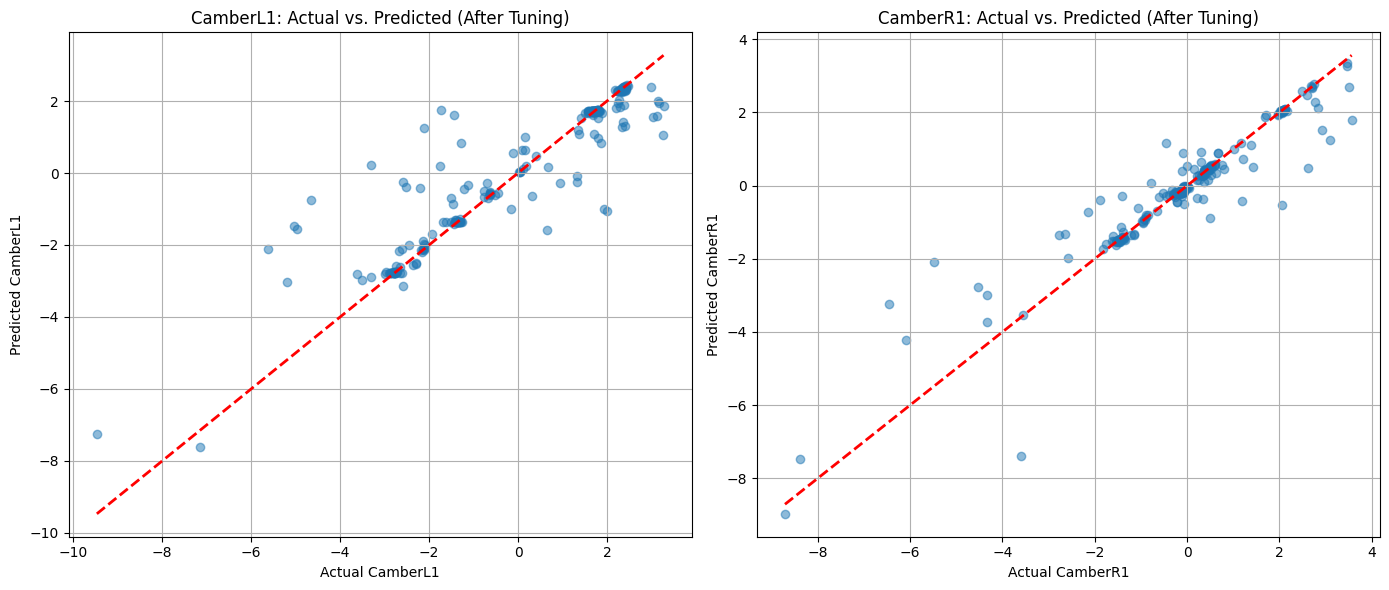

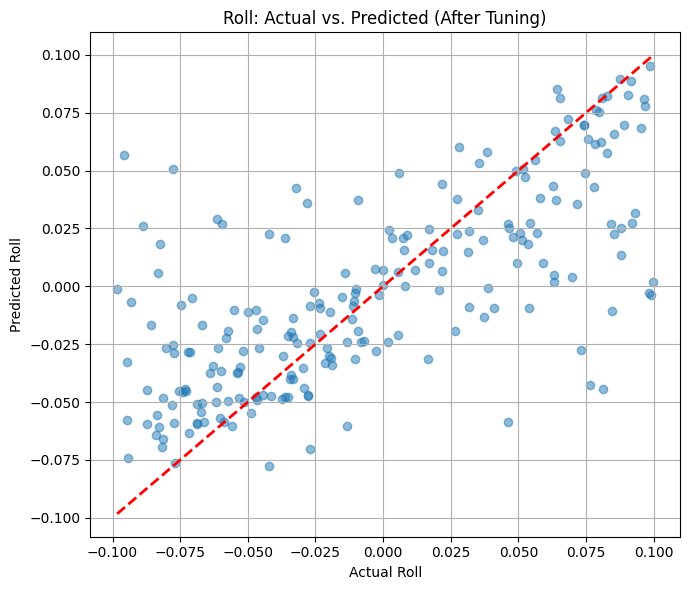

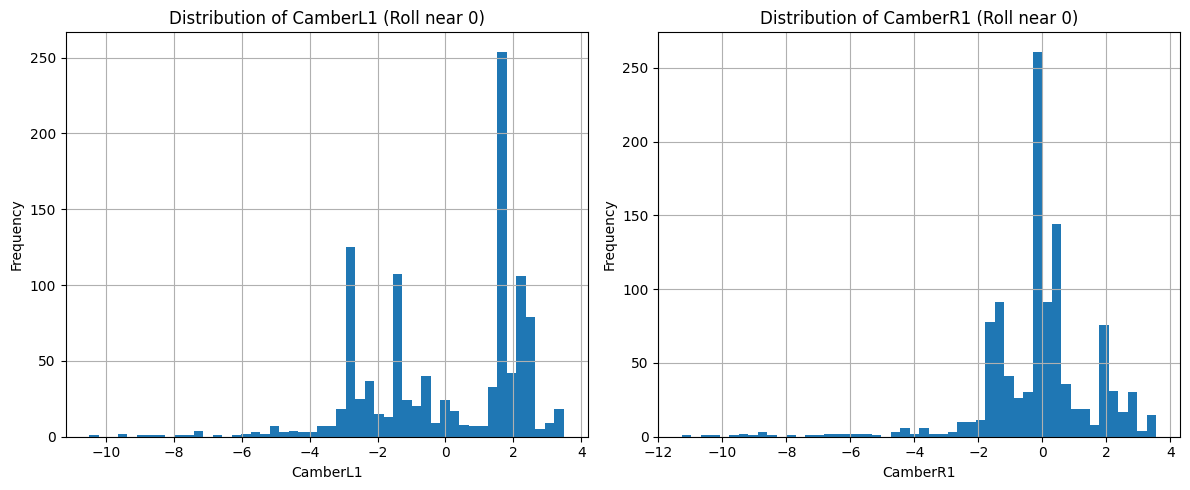

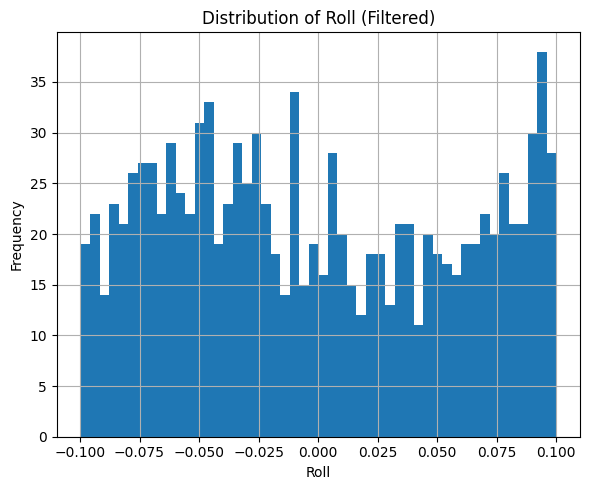

In [16]:
#The Visualization section remains the same
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.scatter(y_test_camber, y_pred_camber, alpha=0.5)
# Add the ideal line (actual == predicted)
plt.plot([y_test_camber.min(), y_test_camber.max()], [y_test_camber.min(), y_test_camber.max()], 'r--', lw=2)
plt.xlabel("Actual CamberL1")
plt.ylabel("Predicted CamberL1")
plt.title("CamberL1: Actual vs. Predicted (After Tuning)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y_test_toe, y_pred_toe, alpha=0.5)
# Add the ideal line (actual == predicted)
plt.plot([y_test_toe.min(), y_test_toe.max()], [y_test_toe.min(), y_test_toe.max()], 'r--', lw=2)
plt.xlabel("Actual CamberR1")
plt.ylabel("Predicted CamberR1")
plt.title("CamberR1: Actual vs. Predicted (After Tuning)")
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
plt.scatter(y_test_roll, y_pred_roll, alpha=0.5)
plt.plot([y_test_roll.min(), y_test_roll.max()], [y_test_roll.min(), y_test_roll.max()], 'r--', lw=2)
plt.xlabel("Actual Roll")
plt.ylabel("Predicted Roll")
plt.title("Roll: Actual vs. Predicted (After Tuning)")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df_filtered['CamberL1'].hist(bins=50)
plt.title('Distribution of CamberL1 (Roll near 0)')
plt.xlabel('CamberL1')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
df_filtered['CamberR1'].hist(bins=50)
plt.title('Distribution of CamberR1 (Roll near 0)')
plt.xlabel('CamberR1')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
df_filtered['Roll'].hist(bins=50)
plt.title('Distribution of Roll (Filtered)')
plt.xlabel('Roll')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [13]:
# --- Decision Tree Visualization using export_graphviz ---

# Extract one tree from the Random Forest
# RandomForestRegressor stores individual trees in its 'estimators_' attribute
# We'll take the first tree for demonstration.
single_tree_to_visualize = model_camber.estimators_[0]

# Export as .dot file
# max_depth is crucial for readability; start with a small number like 3 or 4 for posters.
dot_data = export_graphviz(single_tree_to_visualize,
                           feature_names=features, # Use your defined features list
                           filled=True,           # Color nodes by their predicted value
                           rounded=True,          # Round the corners of the node boxes
                           special_characters=True,
                           out_file=None,         # Output directly as a string
                           max_depth=3,           # Limit depth for readability on poster
                           precision=2)           # Number of decimal places for values

# Create a graph from dot data and render it
graph = graphviz.Source(dot_data)

# Save the graph to a file (e.g., PNG, SVG, PDF) and optionally open it
graph_file_name = "single_decision_tree_camber"
graph.render(graph_file_name, format="png", view=True) # Renders and opens the .png file

print(f"Decision tree visualization saved to {graph_file_name}.png")

# If you are in a Jupyter Notebook/Colab and want to display it inline without saving to file:
# graph

Decision tree visualization saved to single_decision_tree_camber.png
